In [26]:
from pathlib import Path
import pandas as pd
import numpy as np

# ================== 参数 ==================
data_dir    = Path("nn_input_data_all")   # 如果不需要读目录，直接把 all_df 换成你现有的 DataFrame 即可
usecols     = None                       # 只读需要列可指定为列表；否则 None
time_col    = None                       # 例如 "time"；若没有/无效则会退化到行号排序
eps         = 0.0                        # “等于0”的阈值；如需容忍微小误差可改为 1e-12
check_cols  = ['U_int', 'U_int_Fx', 'U_int_Fy', 'U_int_Fz', 'U_int_Fmag']  # 用这几列判断是否“全为0”
save_path   = None                       # 例如 "balanced.csv"；不保存则设为 None
random_offset = 0                        # 系统抽样的起点偏移（0~stride-1），改成固定整数即可复现

# ================== 读取与拼接（可选） ==================
csv_files = sorted(data_dir.glob("*.csv"))
dfs = []
for p in csv_files:
    df = pd.read_csv(p, usecols=usecols)
    df["__file__"] = p.name
    dfs.append(df)
if dfs:
    all_df = pd.concat(dfs, ignore_index=True)
else:
    # 如果你已经有 all_df，就把上面读取部分删掉，保留这一句占位即可：
    raise RuntimeError(f"目录 {data_dir} 下未发现 CSV；若你已有 all_df，请直接用它。")

# ================== 排序键准备（时间优先，否则行号） ==================
if time_col is not None and time_col in all_df.columns:
    # 尝试转成 datetime；失败则置为 NaT，后续会退化到行号
    all_df[time_col] = pd.to_datetime(all_df[time_col], errors="coerce")

if (time_col is None) or (time_col not in all_df.columns) or all_df[time_col].isna().all():
    time_col = None
    # 用数据原始顺序生成稳定行号
    all_df["__row__"] = np.arange(len(all_df))
    sort_key = ["__row__"]
else:
    # 若存在有效时间列，保持时间顺序（稳定排序）
    sort_key = [time_col]

all_df = all_df.sort_values(sort_key, kind="mergesort").reset_index(drop=True)

# ================== 判定“是否全为0” ==================
# 只用 check_cols 来判断；若某列缺失会抛错以避免误判
missing = [c for c in check_cols if c not in all_df.columns]
if missing:
    raise KeyError(f"下列用于判断的列在数据中缺失：{missing}")

is_all_zero = all_df[check_cols].abs().le(eps).all(axis=1)
df_zero  = all_df.loc[is_all_zero].copy()
df_nonzero = all_df.loc[~is_all_zero].copy()

N_z  = len(df_zero)
N_nz = len(df_nonzero)

print(f"非0样本数: {N_nz} | 全0样本数: {N_z}")

# ================== 系统抽样，使“全0样本”数量 == “非0样本”数量 ==================
if N_nz == 0:
    # 只有全0数据，无法对齐为相同数量，直接返回空或全部
    df_zero_sys = pd.DataFrame(columns=all_df.columns)
    print("[警告] 非0样本为 0，返回空平衡集。")
elif N_z == 0:
    # 没有全0数据，不需要抽样
    df_zero_sys = pd.DataFrame(columns=all_df.columns)
    print("[信息] 全0样本为 0，无需抽样。")
else:
    # 计算步长 stride：从全0集中每隔 stride 取一条，直到约等于 N_nz 条
    stride = max(1, int(np.floor(N_z / N_nz)))
    # 允许设置一个起点偏移，增强可复现性/公平性
    start = random_offset % stride
    take_idx = np.arange(start, N_z, stride)

    # 可能多于 N_nz，截断到恰好 N_nz；若少于 N_nz（当 N_z < N_nz），则只能取到 N_z 条
    if len(take_idx) >= N_nz:
        take_idx = take_idx[:N_nz]

    df_zero_sys = df_zero.iloc[take_idx].copy()
    print(f"系统抽样步长: {stride} | 起点偏移: {start} | 抽取全0样本数: {len(df_zero_sys)}")

# ================== 合并为平衡数据集 ==================
df_balanced = pd.concat([df_nonzero, df_zero_sys], ignore_index=True)

# 为了保持全局时间顺序/行序，按 sort_key 再次稳定排序
df_balanced = df_balanced.sort_values(sort_key, kind="mergesort").reset_index(drop=True)

print(f"平衡后总样本数: {len(df_balanced)}（非0: {len(df_nonzero)} + 全0抽样: {len(df_zero_sys)}）")


非0样本数: 66847 | 全0样本数: 1358749
系统抽样步长: 20 | 起点偏移: 0 | 抽取全0样本数: 66847
平衡后总样本数: 133694（非0: 66847 + 全0抽样: 66847）


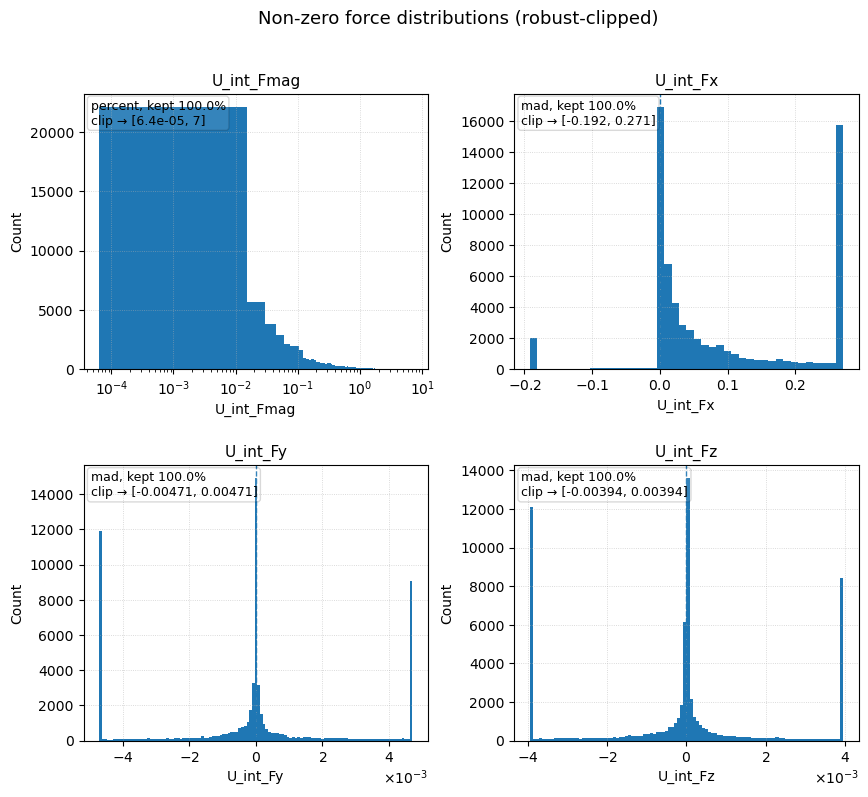

In [27]:
# ================== 非0部分直方图（美化标题&说明） ==================
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter

hist_cols = ['U_int_Fmag', 'U_int_Fx', 'U_int_Fy', 'U_int_Fz']

def robust_clip(s: pd.Series, method='percent', **kw):
    s = s.replace([np.inf, -np.inf], np.nan).dropna()
    if s.empty:
        return s, (None, None)
    if method == 'percent':
        lo = kw.get('lo', 0.005); hi = kw.get('hi', 0.995)
        a, b = s.quantile([lo, hi]).values
        return s.clip(a, b), (a, b)
    elif method == 'iqr':
        k = kw.get('k', 1.5)
        q1, q3 = s.quantile([0.25, 0.75]).values
        iqr = q3 - q1; a, b = q1 - k*iqr, q3 + k*iqr
        return s.clip(a, b), (a, b)
    elif method == 'mad':
        k = kw.get('k', 4.0)
        med = s.median(); mad = (s - med).abs().median()
        scale = 1.4826 * mad if mad > 0 else s.std()
        a, b = med - k*scale, med + k*scale
        return s.clip(a, b), (a, b)
    else:
        raise ValueError("Unknown method")

method_cfg = {
    'U_int_Fmag': ('percent', dict(lo=0.005, hi=0.995)),
    'U_int_Fx':   ('mad',     dict(k=4.0)),
    'U_int_Fy':   ('mad',     dict(k=4.0)),
    'U_int_Fz':   ('mad',     dict(k=4.0)),
}

# 画图
rows, cols = 2, 2
fig, axes = plt.subplots(rows, cols, figsize=(5*cols, 4.2*rows))
axes = axes.ravel()

# 总标题，减少每个小图标题长度
fig.suptitle("Non-zero force distributions (robust-clipped)", fontsize=13, y=0.98)

for i, col in enumerate(hist_cols):
    ax = axes[i]
    raw = df_nonzero[col].replace([np.inf, -np.inf], np.nan).dropna()
    if raw.empty:
        ax.set_visible(False)
        continue

    method, params = method_cfg.get(col, ('percent', dict(lo=0.01, hi=0.99)))
    s_clip, (a, b) = robust_clip(raw, method=method, **params)
    kept_ratio = len(s_clip) / len(raw) * 100

    # 直方图
    ax.hist(s_clip.values, bins='auto')
    ax.axvline(0.0, linestyle='--', linewidth=1)
    ax.grid(True, linestyle=':', linewidth=0.6, alpha=0.6)

    # x 轴格式：Fmag 常用对数坐标，其它保持线性
    if col == 'U_int_Fmag' and (s_clip > 0).any():
        ax.set_xscale('log')
    else:
        ax.xaxis.set_major_formatter(ScalarFormatter(useMathText=True))
        ax.ticklabel_format(style='sci', axis='x', scilimits=(-2, 3))

    # 简短标题：只放列名
    ax.set_title(col, fontsize=11, pad=6)
    ax.set_xlabel(col)
    ax.set_ylabel("Count")

    # 把“方法/保留比例/clip区间”做成角落说明，避免和标题挤在一起
    def _fmt(v):
        try:
            return f"{v:.3g}"
        except Exception:
            return str(v)

    if a is not None and b is not None:
        info = f"{method}, kept {kept_ratio:.1f}%\nclip → [{_fmt(a)}, {_fmt(b)}]"
    else:
        info = f"{method}, kept {kept_ratio:.1f}%"

    ax.text(
        0.02, 0.98, info,
        transform=ax.transAxes, va='top', ha='left',
        fontsize=9, bbox=dict(boxstyle='round,pad=0.25', fc=(1,1,1,0.1), ec=(0,0,0,0.15))
    )

# 布局：预留总标题空间，避免重叠
fig.subplots_adjust(top=0.88, wspace=0.25, hspace=0.35)
plt.show()



[A] 四元数分布统计：
 count_total_rows  count_finite_rows   x_mean   x_std  x_min  x_max  y_mean    y_std  y_min  y_max    z_mean    z_std  z_min  z_max   w_mean    w_std  w_min  w_max  norm_mean     norm_std  norm_min  norm_max  frac_w_negative  frac_norm_within_1pct
           133694             133694 0.025152 0.36267   -1.0    1.0 0.00289 0.401557   -1.0    1.0 -0.016088 0.333994   -1.0    1.0 0.404229 0.656787   -1.0    1.0        1.0 2.257757e-07  0.999999  1.000001         0.259301                    1.0


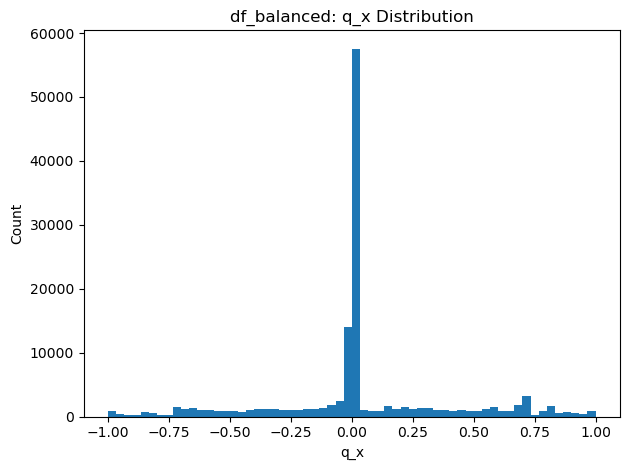

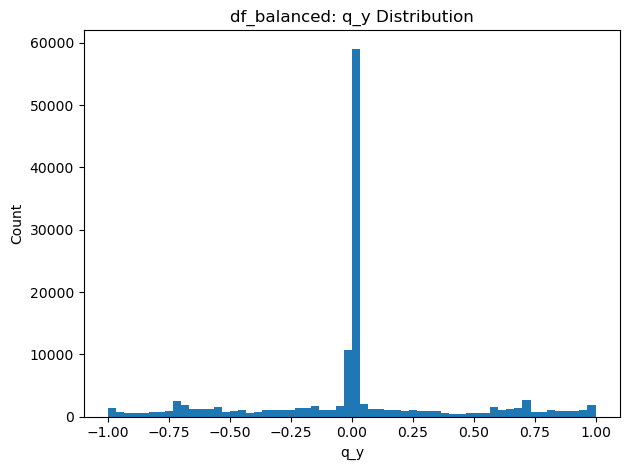

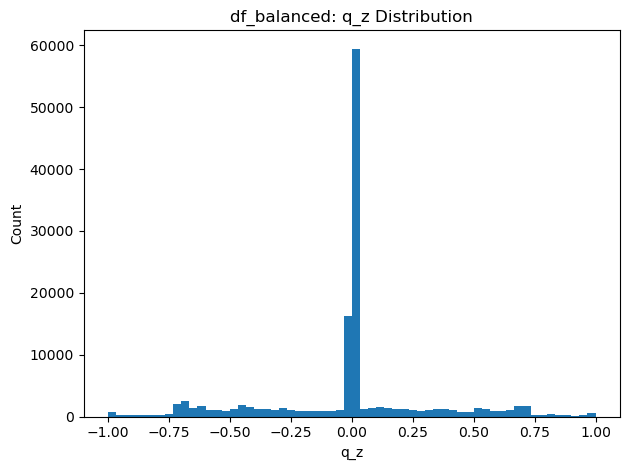

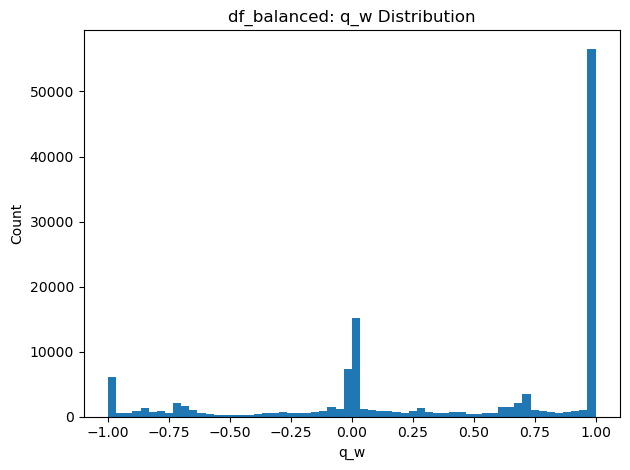

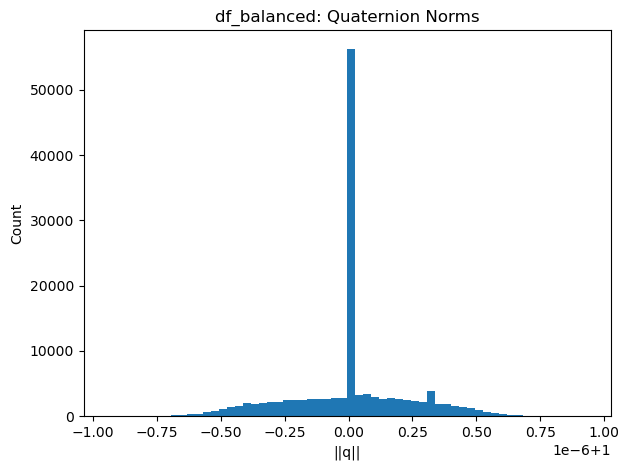


[B] 相邻帧连续性统计：
 pairs_evaluated  median_abs_dot  frac_dot_negative  angle_deg_mean  angle_deg_std  angle_deg_median  angle_deg_p95
          133693             1.0           0.006044        5.485114      25.476479          0.026799      18.618215


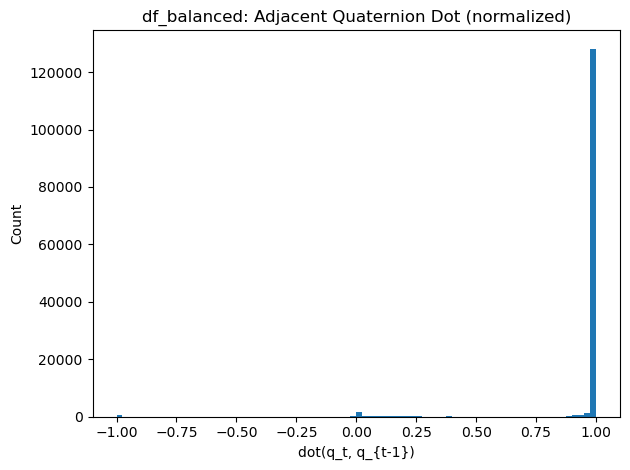

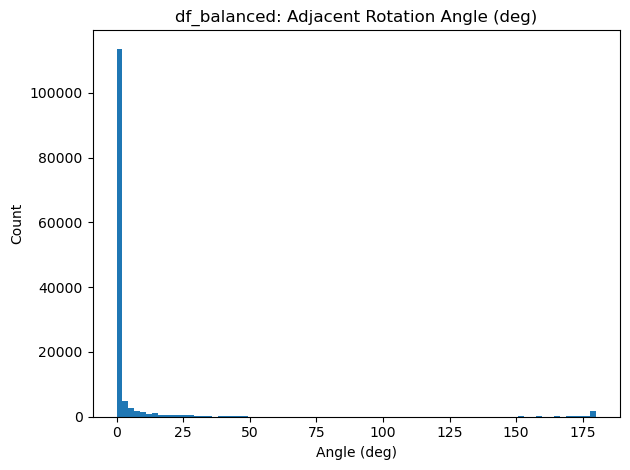

In [28]:
# ================== 对 df_balanced 中四元数列做 A + B 分析 ==================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# ---- 配置：四元数列名（按你的数据命名）----
qx_col, qy_col, qz_col, qw_col = (
    'pair_0_1_qrel_x',
    'pair_0_1_qrel_y',
    'pair_0_1_qrel_z',
    'pair_0_1_qrel_w',
)

# ---- 列存在性检查 ----
quat_missing = [c for c in [qx_col, qy_col, qz_col, qw_col] if c not in df_balanced.columns]
if quat_missing:
    raise KeyError(f"df_balanced 中缺少四元数列: {quat_missing}")

# ---- A) 分布统计（不做归一化，仅计算统计量与范数）----
Q = df_balanced[[qx_col, qy_col, qz_col, qw_col]].to_numpy(dtype=float, copy=True)
norms = np.linalg.norm(Q, axis=1)
finite_mask = np.isfinite(Q).all(axis=1) & np.isfinite(norms)
Qf = Q[finite_mask]
norms_f = norms[finite_mask]

def safe_stats(arr):
    if arr.size == 0:
        return dict(mean=np.nan, std=np.nan, min=np.nan, max=np.nan)
    return dict(mean=float(arr.mean()), std=float(arr.std()), min=float(arr.min()), max=float(arr.max()))

summary_A = {
    'count_total_rows': len(df_balanced),
    'count_finite_rows': int(finite_mask.sum()),
    'x_mean': safe_stats(Qf[:,0])['mean'], 'x_std': safe_stats(Qf[:,0])['std'], 'x_min': safe_stats(Qf[:,0])['min'], 'x_max': safe_stats(Qf[:,0])['max'],
    'y_mean': safe_stats(Qf[:,1])['mean'], 'y_std': safe_stats(Qf[:,1])['std'], 'y_min': safe_stats(Qf[:,1])['min'], 'y_max': safe_stats(Qf[:,1])['max'],
    'z_mean': safe_stats(Qf[:,2])['mean'], 'z_std': safe_stats(Qf[:,2])['std'], 'z_min': safe_stats(Qf[:,2])['min'], 'z_max': safe_stats(Qf[:,2])['max'],
    'w_mean': safe_stats(Qf[:,3])['mean'], 'w_std': safe_stats(Qf[:,3])['std'], 'w_min': safe_stats(Qf[:,3])['min'], 'w_max': safe_stats(Qf[:,3])['max'],
    'norm_mean': safe_stats(norms_f)['mean'], 'norm_std': safe_stats(norms_f)['std'], 'norm_min': safe_stats(norms_f)['min'], 'norm_max': safe_stats(norms_f)['max'],
    'frac_w_negative': float(np.mean(Qf[:,3] < 0.0)) if Qf.size else np.nan,
    'frac_norm_within_1pct': float(np.mean(np.abs(norms_f - 1.0) <= 0.01)) if norms_f.size else np.nan,
}
summary_A_df = pd.DataFrame([summary_A])
print("\n[A] 四元数分布统计：")
print(summary_A_df.to_string(index=False))

# ---- 画 A 的直方图（每个单独一张，不指定颜色）----
if Qf.size:
    plt.figure(); plt.hist(Qf[:,0], bins=60); plt.title("df_balanced: q_x Distribution"); plt.xlabel("q_x"); plt.ylabel("Count"); plt.tight_layout(); plt.show()
    plt.figure(); plt.hist(Qf[:,1], bins=60); plt.title("df_balanced: q_y Distribution"); plt.xlabel("q_y"); plt.ylabel("Count"); plt.tight_layout(); plt.show()
    plt.figure(); plt.hist(Qf[:,2], bins=60); plt.title("df_balanced: q_z Distribution"); plt.xlabel("q_z"); plt.ylabel("Count"); plt.tight_layout(); plt.show()
    plt.figure(); plt.hist(Qf[:,3], bins=60); plt.title("df_balanced: q_w Distribution"); plt.xlabel("q_w"); plt.ylabel("Count"); plt.tight_layout(); plt.show()
    plt.figure(); plt.hist(norms_f, bins=60); plt.title("df_balanced: Quaternion Norms"); plt.xlabel("||q||"); plt.ylabel("Count"); plt.tight_layout(); plt.show()

# ---- B) 相邻帧连续性分析（按当前排序，若你有时间列可在前面已排序）----
def pairwise_dot_and_angle(Qarr: np.ndarray):
    """返回相邻帧的点积(单元化后)与旋转角度（度），角度用最短弧 2*acos(|dot|)。"""
    n = Qarr.shape[0]
    if n < 2:
        return np.array([]), np.array([])
    q_prev = Qarr[:-1]
    q_curr = Qarr[1:]
    # 仅用于角度计算的内部单位化（不改动外部数据）
    n_prev = np.linalg.norm(q_prev, axis=1, keepdims=True)
    n_curr = np.linalg.norm(q_curr, axis=1, keepdims=True)
    n_prev[n_prev == 0] = np.nan
    n_curr[n_curr == 0] = np.nan
    d = np.sum(q_prev*q_curr, axis=1) / (n_prev.squeeze() * n_curr.squeeze())
    d = np.clip(d, -1.0, 1.0)
    angles = 2.0 * np.degrees(np.arccos(np.abs(d)))  # 取绝对值以避免 ±q 跳相
    return d, angles

d_adj, angles_deg = pairwise_dot_and_angle(Qf)
summary_B = {
    "pairs_evaluated": int(d_adj.size),
    "median_abs_dot": float(np.nanmedian(np.abs(d_adj))) if d_adj.size else np.nan,
    "frac_dot_negative": float(np.mean(d_adj < 0)) if d_adj.size else np.nan,
    "angle_deg_mean": float(np.nanmean(angles_deg)) if angles_deg.size else np.nan,
    "angle_deg_std": float(np.nanstd(angles_deg)) if angles_deg.size else np.nan,
    "angle_deg_median": float(np.nanmedian(angles_deg)) if angles_deg.size else np.nan,
    "angle_deg_p95": float(np.nanpercentile(angles_deg, 95)) if angles_deg.size else np.nan,
}
summary_B_df = pd.DataFrame([summary_B])
print("\n[B] 相邻帧连续性统计：")
print(summary_B_df.to_string(index=False))

# ---- 画 B 的直方图 ----
if d_adj.size:
    plt.figure(); plt.hist(d_adj, bins=80); plt.title("df_balanced: Adjacent Quaternion Dot (normalized)"); plt.xlabel("dot(q_t, q_{t-1})"); plt.ylabel("Count"); plt.tight_layout(); plt.show()
    plt.figure(); plt.hist(angles_deg, bins=80); plt.title("df_balanced: Adjacent Rotation Angle (deg)"); plt.xlabel("Angle (deg)"); plt.ylabel("Count"); plt.tight_layout(); plt.show()

[GRU式处理] 异常置 I 行数: 0 | 唯一化翻转数: 34667

[A_g] 四元数分布统计（GRU式处理后）：
 count_total_rows  count_finite_rows   x_mean    x_std  x_min  x_max    y_mean    y_std  y_min  y_max   z_mean    z_std  z_min  z_max   w_mean    w_std  w_min  w_max  norm_mean     norm_std  norm_min  norm_max  frac_w_negative  frac_norm_within_1ppm
           133694             133694 0.045499 0.360683   -1.0    1.0 -0.025842 0.400735   -1.0    1.0 -0.03235 0.332812   -1.0    1.0 0.657989 0.402271    0.0    1.0        1.0 6.291584e-17       1.0       1.0              0.0                    1.0


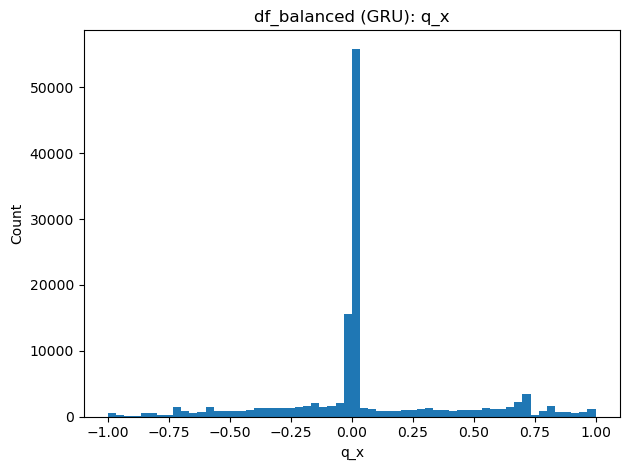

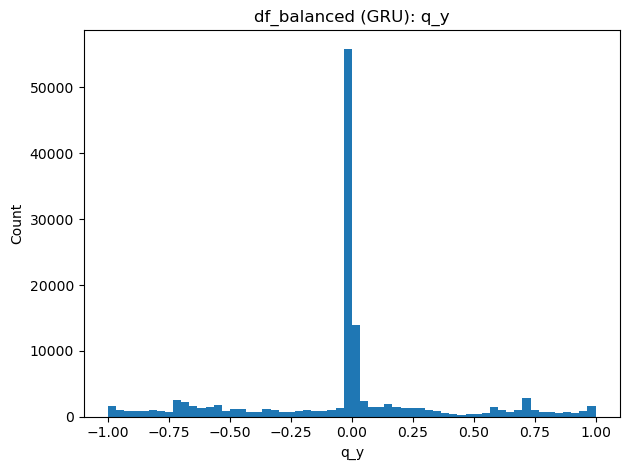

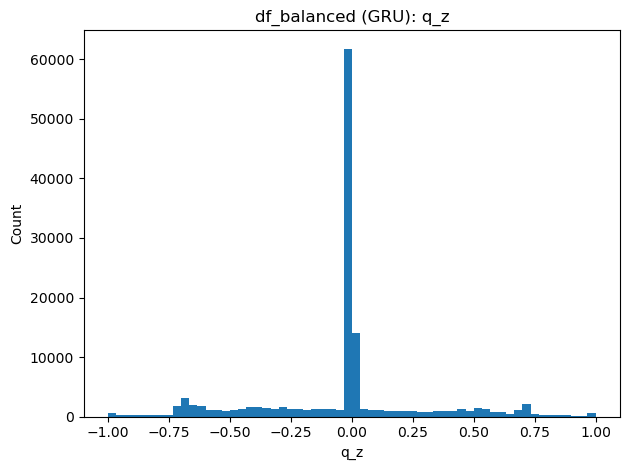

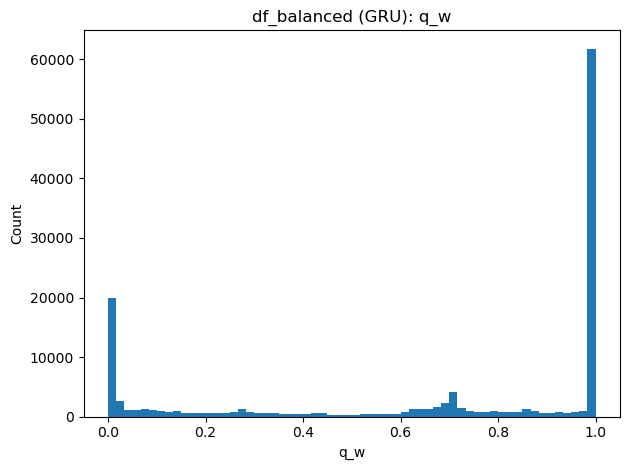

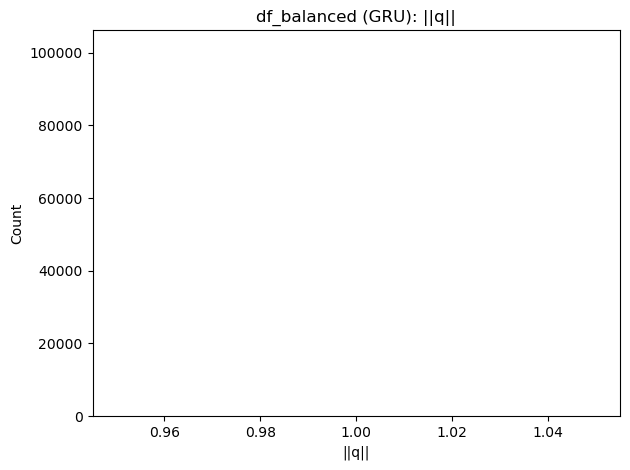


[B_g] 相邻帧连续性统计（GRU式处理后）：
 pairs  median_abs_dot  frac_dot_negative  angle_mean_deg  angle_median_deg  angle_p95_deg
133693             1.0           0.011085        5.485114          0.026799      18.618215


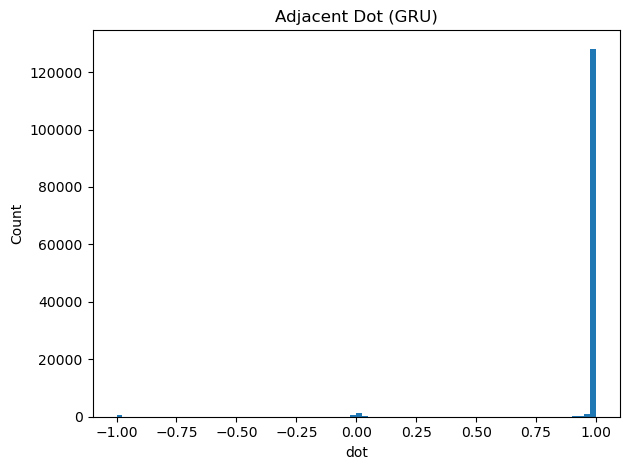

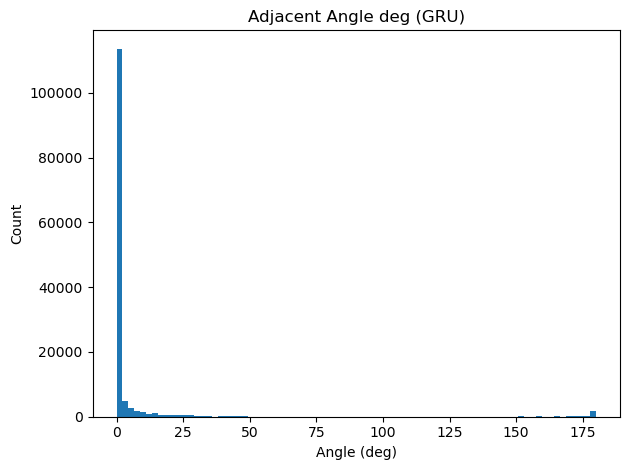

In [29]:
# 列名
qx, qy, qz, qw = 'pair_0_1_qrel_x','pair_0_1_qrel_y','pair_0_1_qrel_z','pair_0_1_qrel_w'
cols = [qx,qy,qz,qw]

# 取原四元数
Q = df_balanced[cols].to_numpy(dtype=float, copy=True)

# 1) 计算范数并做“异常置 I=[0,0,0,1]”
norms = np.linalg.norm(Q, axis=1)
finite = np.isfinite(Q).all(axis=1) & np.isfinite(norms)
safe = finite & (norms > 1e-9)

Q_fixed = Q.copy()
# 异常行置单位四元数
bad_mask = ~safe
if bad_mask.any():
    Q_fixed[bad_mask] = np.array([0.0, 0.0, 0.0, 1.0], dtype=float)

# 2) 单位化（只对 safe 行；bad 行已是单位四元数）
norms_fixed = np.linalg.norm(Q_fixed, axis=1, keepdims=True)
safe2 = norms_fixed.squeeze() > 0
Q_fixed[safe2] = Q_fixed[safe2] / norms_fixed[safe2]

# 3) 点态唯一化：w>=0（整体乘 -1）
flips = (Q_fixed[:,3] < 0).sum()
Q_fixed[Q_fixed[:,3] < 0] *= -1.0

print(f"[GRU式处理] 异常置 I 行数: {int(bad_mask.sum())} | 唯一化翻转数: {int(flips)}")

# 写回 *_g 列
df_balanced[qx+'_g'] = Q_fixed[:,0]
df_balanced[qy+'_g'] = Q_fixed[:,1]
df_balanced[qz+'_g'] = Q_fixed[:,2]
df_balanced[qw+'_g'] = Q_fixed[:,3]

# ================== 用 *_g 列做 A + B 分析 ==================
def safe_stats(arr):
    if arr.size == 0:
        return dict(mean=np.nan, std=np.nan, min=np.nan, max=np.nan)
    return dict(mean=float(arr.mean()), std=float(arr.std()),
                min=float(arr.min()), max=float(arr.max()))

Qg = df_balanced[[qx+'_g', qy+'_g', qz+'_g', qw+'_g']].to_numpy(dtype=float, copy=True)
Ng = np.linalg.norm(Qg, axis=1)

finite_g = np.isfinite(Qg).all(axis=1) & np.isfinite(Ng)
Qg_f = Qg[finite_g]
Ng_f = Ng[finite_g]

summary_Ag = {
    'count_total_rows': len(df_balanced),
    'count_finite_rows': int(finite_g.sum()),
    'x_mean': safe_stats(Qg_f[:,0])['mean'], 'x_std': safe_stats(Qg_f[:,0])['std'], 'x_min': safe_stats(Qg_f[:,0])['min'], 'x_max': safe_stats(Qg_f[:,0])['max'],
    'y_mean': safe_stats(Qg_f[:,1])['mean'], 'y_std': safe_stats(Qg_f[:,1])['std'], 'y_min': safe_stats(Qg_f[:,1])['min'], 'y_max': safe_stats(Qg_f[:,1])['max'],
    'z_mean': safe_stats(Qg_f[:,2])['mean'], 'z_std': safe_stats(Qg_f[:,2])['std'], 'z_min': safe_stats(Qg_f[:,2])['min'], 'z_max': safe_stats(Qg_f[:,2])['max'],
    'w_mean': safe_stats(Qg_f[:,3])['mean'], 'w_std': safe_stats(Qg_f[:,3])['std'], 'w_min': safe_stats(Qg_f[:,3])['min'], 'w_max': safe_stats(Qg_f[:,3])['max'],
    'norm_mean': safe_stats(Ng_f)['mean'], 'norm_std': safe_stats(Ng_f)['std'], 'norm_min': safe_stats(Ng_f)['min'], 'norm_max': safe_stats(Ng_f)['max'],
    'frac_w_negative': float(np.mean(Qg_f[:,3] < 0.0)) if Qg_f.size else np.nan,   # 应接近 0
    'frac_norm_within_1ppm': float(np.mean(np.abs(Ng_f-1.0) <= 1e-6)) if Ng_f.size else np.nan,
}
summary_Ag_df = pd.DataFrame([summary_Ag])
print("\n[A_g] 四元数分布统计（GRU式处理后）：")
print(summary_Ag_df.to_string(index=False))

# 直方图（每图单独，不设颜色）
if Qg_f.size:
    plt.figure(); plt.hist(Qg_f[:,0], bins=60); plt.title("df_balanced (GRU): q_x"); plt.xlabel("q_x"); plt.ylabel("Count"); plt.tight_layout(); plt.show()
    plt.figure(); plt.hist(Qg_f[:,1], bins=60); plt.title("df_balanced (GRU): q_y"); plt.xlabel("q_y"); plt.ylabel("Count"); plt.tight_layout(); plt.show()
    plt.figure(); plt.hist(Qg_f[:,2], bins=60); plt.title("df_balanced (GRU): q_z"); plt.xlabel("q_z"); plt.ylabel("Count"); plt.tight_layout(); plt.show()
    plt.figure(); plt.hist(Qg_f[:,3], bins=60); plt.title("df_balanced (GRU): q_w"); plt.xlabel("q_w"); plt.ylabel("Count"); plt.tight_layout(); plt.show()
    plt.figure(); plt.hist(Ng_f, bins=60);  plt.title("df_balanced (GRU): ||q||"); plt.xlabel("||q||"); plt.ylabel("Count"); plt.tight_layout(); plt.show()

# —— B：相邻帧连续性（用 *_g 列；内部临时单位化计算角度，不改数据）——
def pairwise_dot_and_angle(Qarr: np.ndarray):
    n = Qarr.shape[0]
    if n < 2:
        return np.array([]), np.array([])
    a = Qarr[:-1]; b = Qarr[1:]
    na = np.linalg.norm(a, axis=1, keepdims=True); na[na==0]=np.nan
    nb = np.linalg.norm(b, axis=1, keepdims=True); nb[nb==0]=np.nan
    d = np.sum(a*b, axis=1) / (na.squeeze()*nb.squeeze())
    d = np.clip(d, -1.0, 1.0)
    ang = 2.0*np.degrees(np.arccos(np.abs(d)))  # 最短弧
    return d, ang

d_g, ang_g = pairwise_dot_and_angle(Qg_f)
summary_Bg = pd.DataFrame([{
    "pairs": int(d_g.size),
    "median_abs_dot": float(np.nanmedian(np.abs(d_g))) if d_g.size else np.nan,
    "frac_dot_negative": float(np.mean(d_g < 0)) if d_g.size else np.nan,
    "angle_mean_deg": float(np.nanmean(ang_g)) if ang_g.size else np.nan,
    "angle_median_deg": float(np.nanmedian(ang_g)) if ang_g.size else np.nan,
    "angle_p95_deg": float(np.nanpercentile(ang_g, 95)) if ang_g.size else np.nan,
}])
print("\n[B_g] 相邻帧连续性统计（GRU式处理后）：")
print(summary_Bg.to_string(index=False))

if d_g.size:
    plt.figure(); plt.hist(d_g, bins=80);   plt.title("Adjacent Dot (GRU)");   plt.xlabel("dot");   plt.ylabel("Count"); plt.tight_layout(); plt.show()
    plt.figure(); plt.hist(ang_g, bins=80); plt.title("Adjacent Angle deg (GRU)"); plt.xlabel("Angle (deg)"); plt.ylabel("Count"); plt.tight_layout(); plt.show()